In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ashydv/advertising-dataset")

print("Path to dataset files:", path)

100%|██████████████████████████████████████████████████████████████████████████████| 1.83k/1.83k [00:00<00:00, 907kB/s]

Extracting files...
Path to dataset files: C:\Users\DELL\.cache\kagglehub\datasets\ashydv\advertising-dataset\versions\1


In [3]:
import os

print(os.listdir(path))

['advertising.csv']


In [4]:
import pandas as pd

df = pd.read_csv(path + "/Advertising.csv")
print(df.head())

      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9


In [5]:
X = df[["TV"]]
Y = df["Sales"]

Equation: Y = 6.9748214882298925 + 0.05546477046955886 X

Errors:
SSE = 1043.5487795590257
MSE = 5.2177438977951285
RMSE = 2.2842381438447106
MAE = 1.8305872641932412


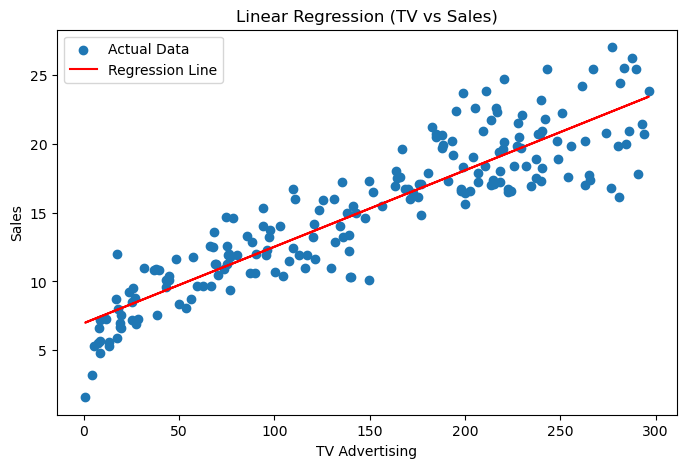

In [10]:
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt
model = LinearRegression()
model.fit(X, Y)
y_pred = model.predict(X)
b0 = model.intercept_
b1 = model.coef_[0]
print("Equation: Y =", b0, "+", b1, "X")
# SSE
sse = np.sum((Y - y_pred) ** 2)
# MSE
mse = np.mean((Y - y_pred) ** 2)
# RMSE
rmse = np.sqrt(mse)
# MAE
mae = np.mean(np.abs(Y - y_pred))
print("\nErrors:")
print("SSE =", sse)
print("MSE =", mse)
print("RMSE =", rmse)
print("MAE =", mae)
plt.figure(figsize=(8,5))
plt.scatter(X, Y, label="Actual Data")
plt.plot(X, y_pred, color="red", label="Regression Line")

plt.xlabel("TV Advertising")
plt.ylabel("Sales")
plt.title("Linear Regression (TV vs Sales)")
plt.legend()
plt.show()

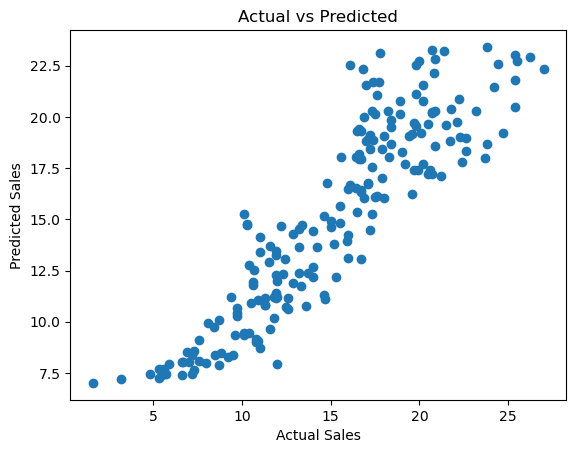

In [11]:
plt.scatter(Y, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted")
plt.show()

In [12]:
X = df[["TV", "Radio", "Newspaper"]]
Y = df["Sales"]

In [13]:
print(df.corr())

                 TV     Radio  Newspaper     Sales
TV         1.000000  0.054809   0.056648  0.901208
Radio      0.054809  1.000000   0.354104  0.349631
Newspaper  0.056648  0.354104   1.000000  0.157960
Sales      0.901208  0.349631   0.157960  1.000000


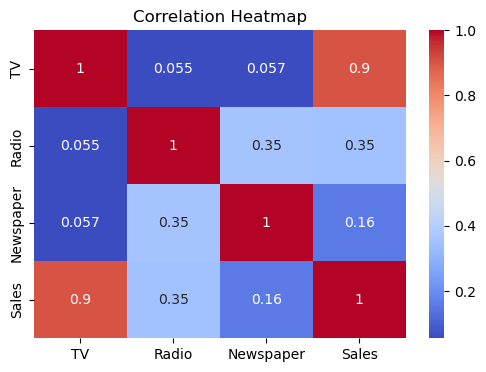

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [19]:
results = pd.DataFrame({
    "Actual": Y.values,
    "Predicted": y_pred,
    "Residual (Error)": residuals.values
})

print("\n" + "="*50)
print("SAMPLE RESULTS")
print("="*50)

print(results.head(10))


SAMPLE RESULTS
   Actual  Predicted  Residual (Error)
0    22.1  19.737265          2.362735
1    10.4   9.443004          0.956996
2    12.0   7.928816          4.071184
3    16.5  15.377734          1.122266
4    17.9  17.002852          0.897148
5     7.2   7.457365         -0.257365
6    11.8  10.164046          1.635954
7    13.2  13.641687         -0.441687
8     4.8   7.451819         -2.651819
9    15.6  18.056683         -2.456683


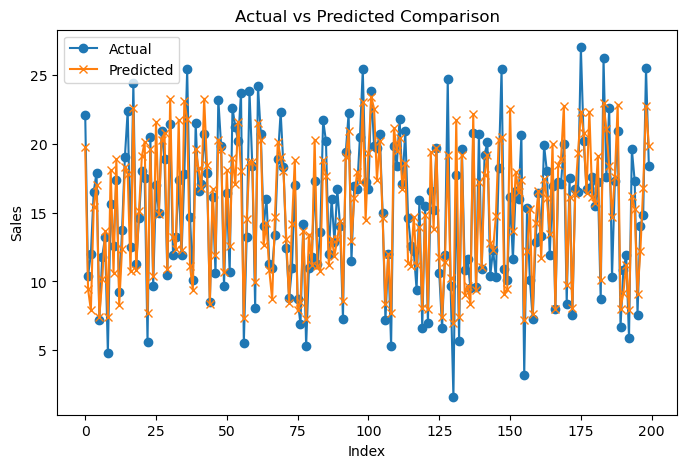

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(results["Actual"].values, label="Actual", marker="o")
plt.plot(results["Predicted"].values, label="Predicted", marker="x")

plt.title("Actual vs Predicted Comparison")
plt.xlabel("Index")
plt.ylabel("Sales")
plt.legend()
plt.show()

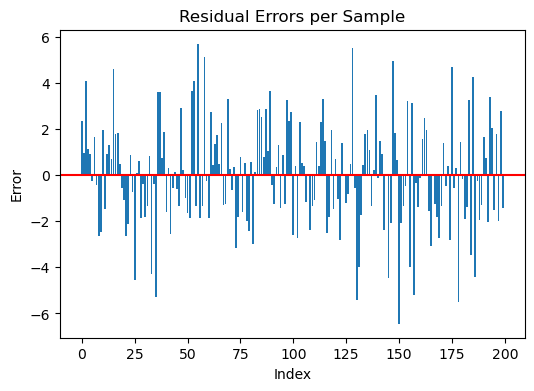

In [22]:
plt.figure(figsize=(6,4))
plt.bar(range(len(results)), results["Residual (Error)"])

plt.axhline(0, color="red")
plt.title("Residual Errors per Sample")
plt.xlabel("Index")
plt.ylabel("Error")
plt.show()